In [5]:
import pandas as pd
import matplotlib.pyplot as plt

lazio_2019 = pd.read_csv("../data/lazio_2019_2020_andata.csv")
lazio_2024 = pd.read_csv("../data/lazio_2024_2025_andata.csv")

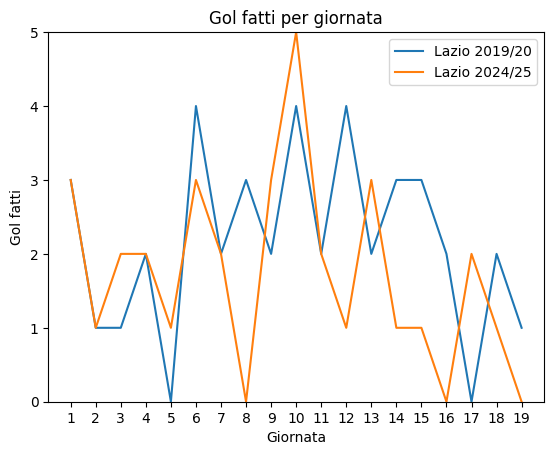

In [6]:
all_gol = pd.concat([lazio_2019["gol_fatti"], lazio_2024["gol_fatti"]])
min_gol = all_gol.min()
max_gol = all_gol.max()

plt.figure()
plt.plot(lazio_2019["giornata"], lazio_2019["gol_fatti"], label="Lazio 2019/20")
plt.plot(lazio_2024["giornata"], lazio_2024["gol_fatti"], label="Lazio 2024/25")
plt.xlabel("Giornata")
plt.ylabel("Gol fatti")
plt.title("Gol fatti per giornata")
plt.xticks(range(1, 20))
plt.yticks(range(min_gol, max_gol + 1))
plt.ylim(min_gol, max_gol)
plt.legend()
plt.show()

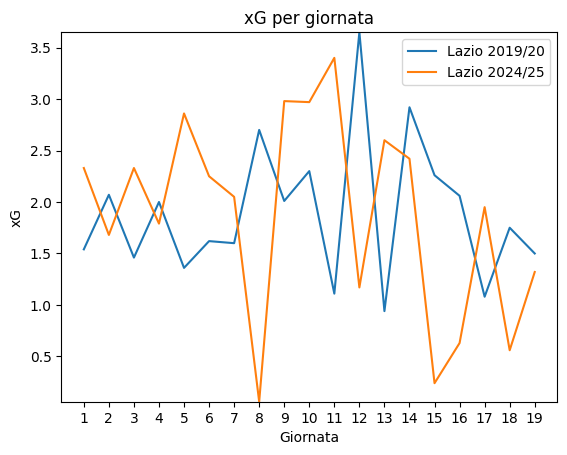

In [7]:
plt.figure()
plt.plot(lazio_2019["giornata"], lazio_2019["xG"], label="Lazio 2019/20")
plt.plot(lazio_2024["giornata"], lazio_2024["xG"], label="Lazio 2024/25")
plt.xlabel("Giornata")
plt.ylabel("xG")
plt.title("xG per giornata")
plt.xticks(range(1, 20))

all_xg = pd.concat([lazio_2019["xG"], lazio_2024["xG"]])
plt.ylim(all_xg.min(), all_xg.max())

plt.legend()
plt.show()

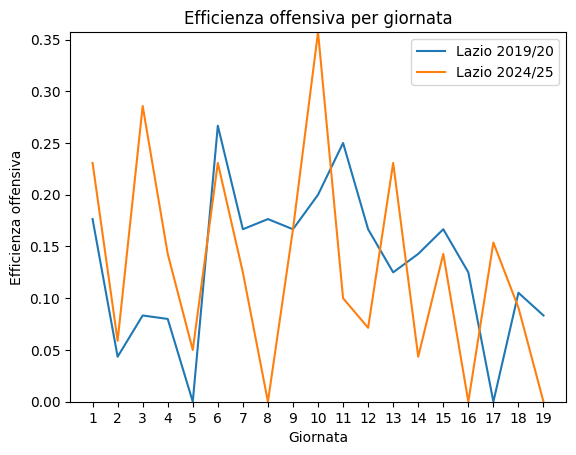

In [8]:
lazio_2019["efficienza_offensiva"] = lazio_2019["gol_fatti"] / lazio_2019["tiri"]
lazio_2024["efficienza_offensiva"] = lazio_2024["gol_fatti"] / lazio_2024["tiri"]

plt.figure()
plt.plot(lazio_2019["giornata"], lazio_2019["efficienza_offensiva"], label="Lazio 2019/20")
plt.plot(lazio_2024["giornata"], lazio_2024["efficienza_offensiva"], label="Lazio 2024/25")
plt.xlabel("Giornata")
plt.ylabel("Efficienza offensiva")
plt.title("Efficienza offensiva per giornata")
plt.xticks(range(1, 20))

all_eff = pd.concat([lazio_2019["efficienza_offensiva"], lazio_2024["efficienza_offensiva"]])
plt.ylim(all_eff.min(), all_eff.max())

plt.legend()
plt.show()

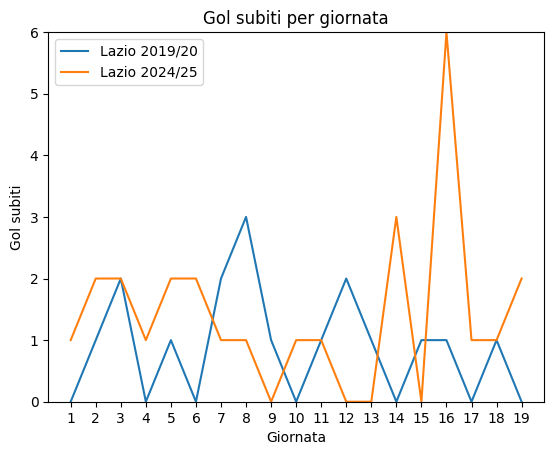

In [9]:
plt.figure()
plt.plot(lazio_2019["giornata"], lazio_2019["gol_subiti"], label="Lazio 2019/20")
plt.plot(lazio_2024["giornata"], lazio_2024["gol_subiti"], label="Lazio 2024/25")
plt.xlabel("Giornata")
plt.ylabel("Gol subiti")
plt.title("Gol subiti per giornata")
plt.xticks(range(1, 20))

all_subiti = pd.concat([lazio_2019["gol_subiti"], lazio_2024["gol_subiti"]])
min_subiti = all_subiti.min()
max_subiti = all_subiti.max()
plt.yticks(range(min_subiti, max_subiti + 1))
plt.ylim(min_subiti, max_subiti)

plt.legend()
plt.show()

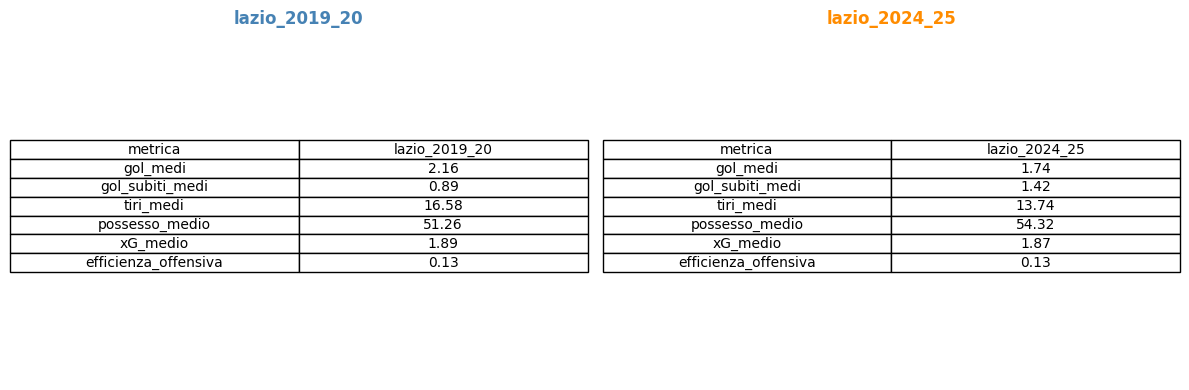

In [11]:
confronto = pd.DataFrame({
    "metrica": ["gol_medi", "gol_subiti_medi", "tiri_medi", "possesso_medio", "xG_medio", "efficienza_offensiva"],
    "lazio_2019_20": [
        lazio_2019["gol_fatti"].mean(),
        lazio_2019["gol_subiti"].mean(),
        lazio_2019["tiri"].mean(),
        lazio_2019["possesso"].mean(),
        lazio_2019["xG"].mean(),
        (lazio_2019["gol_fatti"] / lazio_2019["tiri"]).mean()
    ],
    "lazio_2024_25": [
        lazio_2024["gol_fatti"].mean(),
        lazio_2024["gol_subiti"].mean(),
        lazio_2024["tiri"].mean(),
        lazio_2024["possesso"].mean(),
        lazio_2024["xG"].mean(),
        (lazio_2024["gol_fatti"] / lazio_2024["tiri"]).mean()
    ]
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, stagione, colore in zip(
    axes,
    ["lazio_2019_20", "lazio_2024_25"],
    ["steelblue", "darkorange"]
):
    ax.table(
        cellText=confronto[["metrica", stagione]].round(2).values,
        colLabels=["metrica", stagione],
        loc="center",
        cellLoc="center"
    )
    ax.axis("off")
    ax.set_title(stagione, color=colore, fontweight="bold")

plt.tight_layout()
plt.show()